In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')



In [9]:
pd.set_option('display.max_columns',None)

In [11]:
data=pd.read_csv(r"C:\Users\abc\Downloads\EDA\archive\fraud_dataset.csv",header=0,index_col=0)

In [14]:
data.head(5)

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
step,,,,,,,,,,
1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [15]:
data.columns

Index(['type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [16]:
data.shape

(6362620, 10)

In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 6362620 entries, 1 to 743
Data columns (total 10 columns):
 #   Column          Dtype  
---  ------          -----  
 0   type            object 
 1   amount          float64
 2   nameOrig        object 
 3   oldbalanceOrg   float64
 4   newbalanceOrig  float64
 5   nameDest        object 
 6   oldbalanceDest  float64
 7   newbalanceDest  float64
 8   isFraud         int64  
 9   isFlaggedFraud  int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 534.0+ MB


In [35]:
data.isnull().sum()

type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

<Axes: ylabel='isFraud'>

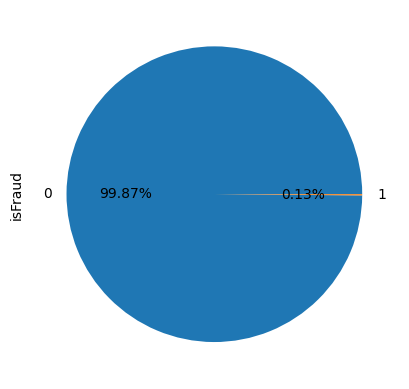

In [45]:
data['isFraud'].value_counts().plot(kind='pie',autopct='%.2f%%')

## Fraud vs. Non-Fraud Distribution (Pie Chart)
## Severe Imbalance: The dataset is extremely imbalanced.

## Non-Fraudulent (isFraud = 0): Accounts for 99.87% of all transactions.

## Fraudulent (isFraud = 1): Represents only 0.13% of all transactions.

In [24]:
data.type.value_counts()

CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: type, dtype: int64

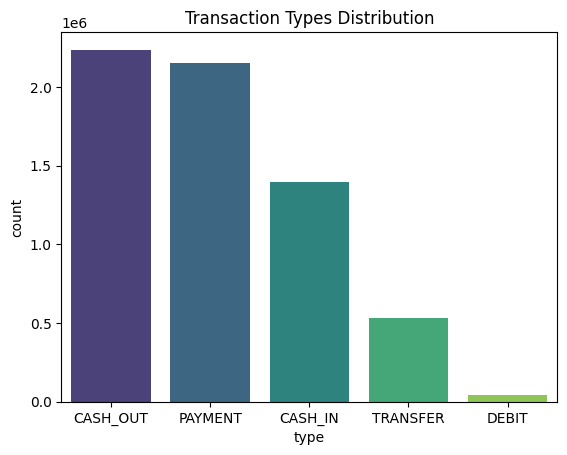

In [54]:
sns.countplot(data=data,x='type',palette='viridis',order=data.type.value_counts().index)
plt.title("Transaction Types Distribution")
plt.show()




## Fraud Only Happens in Two Ways 💡
## Fraudulent activity is not spread across all transaction types; it's highly specific.

## 100% of all fraud occurs in only two types of transactions: CASH_OUT (transferring money from an account to an external service or physical cash) and TRANSFER (moving money between two customer accounts).

## The split is almost 50/50: CASH_OUT has a slight majority (50.11%) of the total fraud cases, with TRANSFER close behind (49.89%).

## No Fraudulent Activity was found in PAYMENT, CASH_IN, or DEBIT transactions.

In [64]:
fraud_rate = data.groupby('type')['isFraud'].mean() * 100
fraud_rate = fraud_rate.round(2)*100  # Round to 2 decimals
print(fraud_rate)


type
CASH_IN      0.0
CASH_OUT    18.0
DEBIT        0.0
PAYMENT      0.0
TRANSFER    77.0
Name: isFraud, dtype: float64


Text(0.5, 1.0, 'Correlation Between Numerical Features')

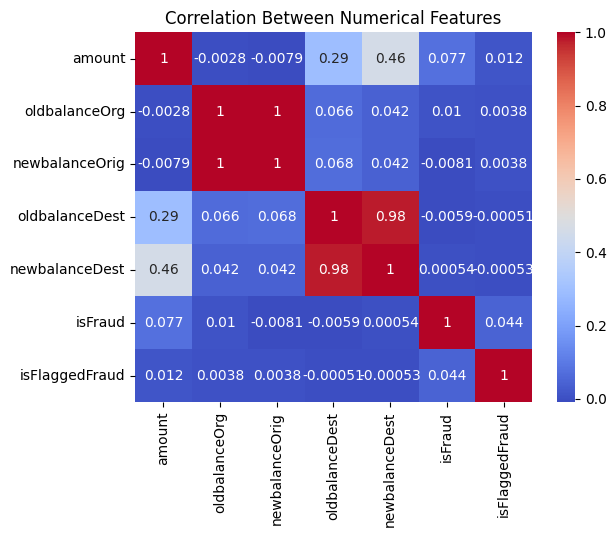

In [75]:
corr = data.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Between Numerical Features")


## Higher Transaction Amounts are Linked to Fraud: The correlation between amount and isFraud is moderate ($0.44$), suggesting that larger transactions are more likely to be fraudulent.Balance Columns are Highly Related to Each Other: This is expected. For example, oldbalanceOrg (old balance of the originating account) and newbalanceOrig (new balance of the originating account) have a very strong relationship ($0.99$) because one is simply the other after the transaction is processed.Absolute Balance Values Aren't Strong Predictors: The correlation between the individual balance columns (like oldbalanceOrg or newbalanceDest) and isFraud is quite low (close to zero). This implies that the total money in an account isn't as predictive as the change in the account's balance.

In [91]:
total_frauds=data[data['isFraud']==1].value_counts().sum()
frauds_type=data[data['isFraud']==1]['type'].value_counts()
print('total_frauds',total_frauds)
print('frauds_type\n',frauds_type)

total_frauds 8213
frauds_type
 CASH_OUT    4116
TRANSFER    4097
Name: type, dtype: int64


<Axes: ylabel='type'>

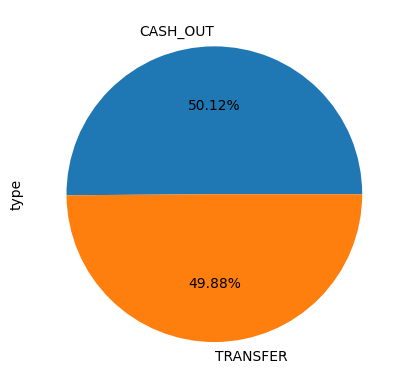

In [92]:
data[data['isFraud']==1]['type'].value_counts().plot(kind='pie',autopct='%.2f%%')

Text(0.5, 1.0, 'Origin Account Balance Change vs Fraud')

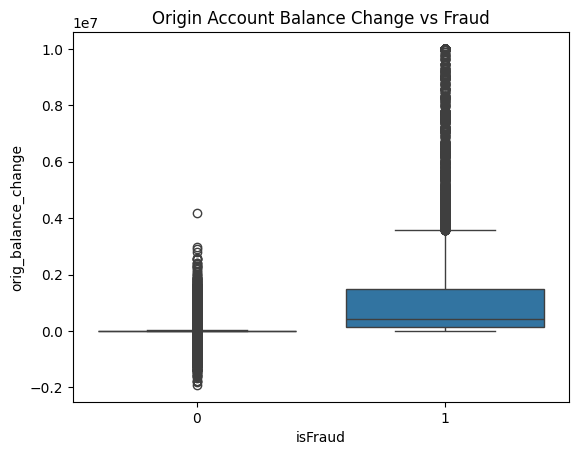

In [97]:
data['orig_balance_change'] = data['oldbalanceOrg'] - data['newbalanceOrig']
data['dest_balance_change'] = data['newbalanceDest'] - data['oldbalanceDest']

sns.boxplot(x='isFraud', y='orig_balance_change', data=data)
plt.title('Origin Account Balance Change vs Fraud')


## Non-Fraud (isFraud = 0): The range of balance change is diverse, with the majority centered near zero or small values. This is expected for typical transactions (payments, small transfers).

## Fraud (isFraud = 1): The balance change for fraudulent transactions is highly concentrated around zero.

## Fraudulent Transactions Often Empty the Account: For most fraudulent transactions, the oldbalanceOrg is completely drained, leaving newbalanceOrig as zero. This means the calculated balance change is equal to the original balance.

## Self-Correction in Code: The feature orig_balance_change is practically identical to the amount for most fraud cases (where newbalanceOrig is 0). The visualization confirms that fraudulent transactions show a distinct pattern of large, non-zero balance changes, corresponding to the full amount being transferred or cashed out.